# scikit-learn을 활용한 1D 피쳐 학습 및 2D 시각화

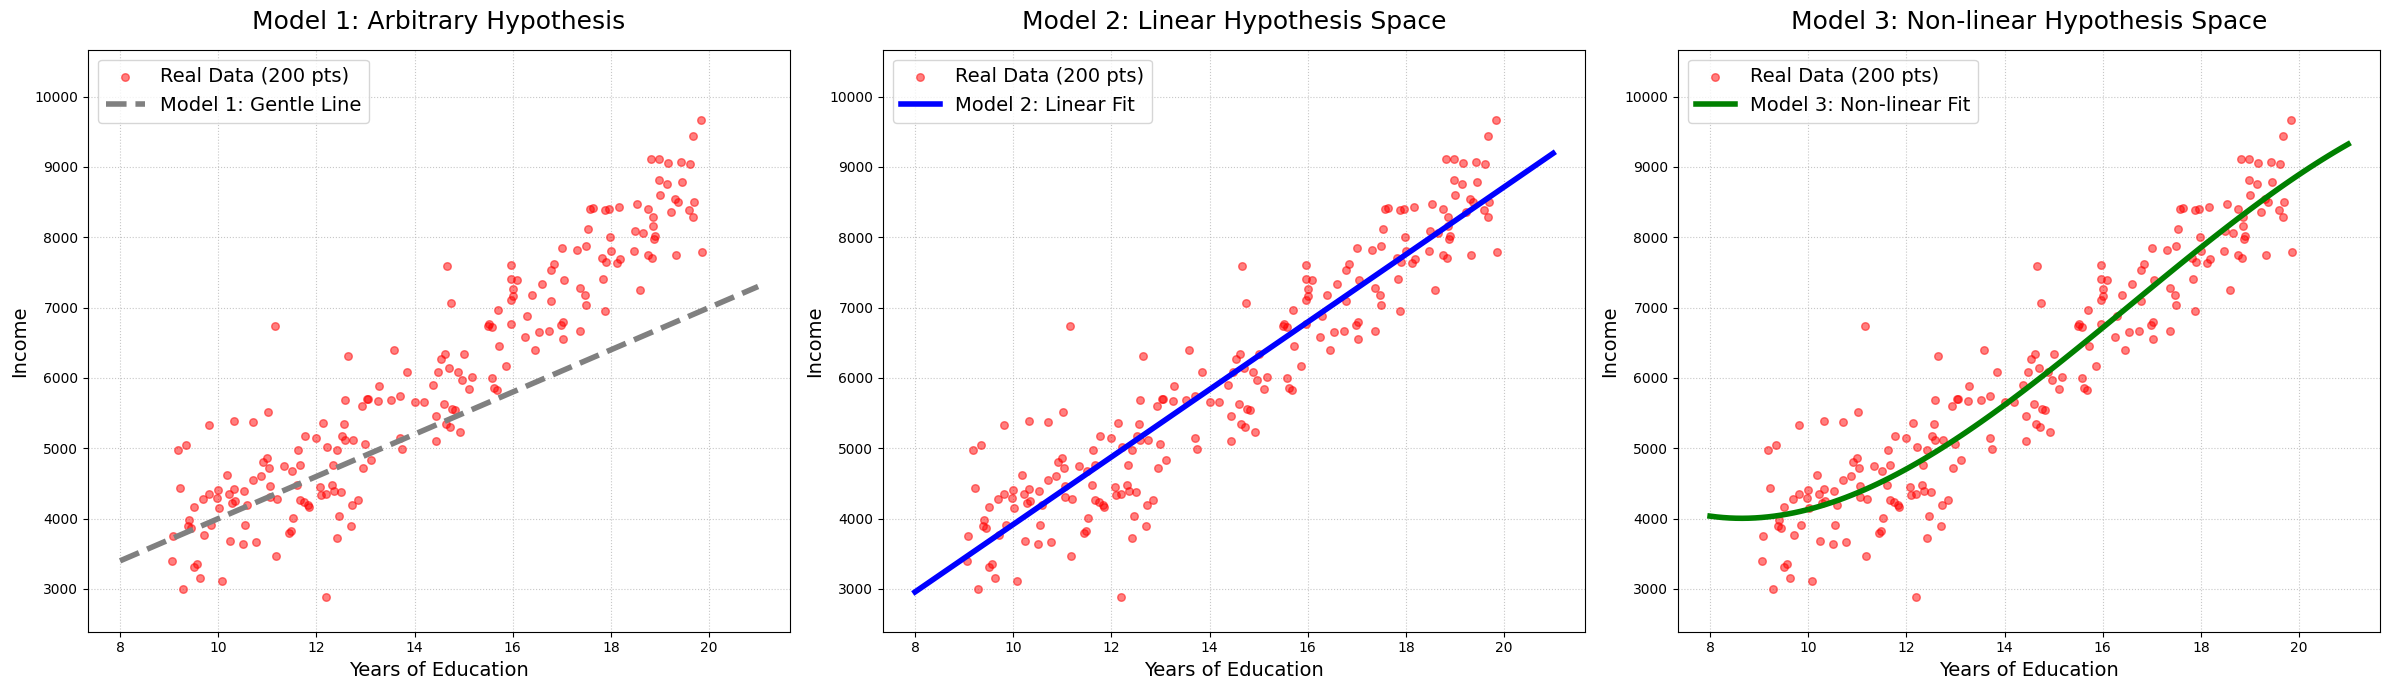

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. 데이터 준비 (데이터 포인트 200개로 대폭 확장)
np.random.seed(42)
num_samples = 200

# X: 교육 연수 (9년 ~ 20년 사이의 랜덤한 값)
X = np.random.uniform(9, 20, num_samples).reshape(-1, 1)

# y: 수입 (현실의 복잡성을 반영하기 위해 살짝 휘어지는 2차 곡선 형태의 진짜 규칙 생성)
y_true = 2000 + 50 * X.flatten() + 15 * (X.flatten() ** 2)
# 측정 오차(노이즈) 추가
y = y_true + np.random.normal(0, 600, num_samples)

# 시각화를 위해 매끄러운 선을 그릴 X_plot 도화지 생성 (8년~21년)
X_plot = np.linspace(8, 21, 100).reshape(-1, 1)

# 2. 세 가지 후보 모델 준비 및 예측

# [후보 1] 완만한 직선 (우리가 임의로 세워본 잘못된 가설)
y_plot_gentle = 300 * X_plot.flatten() + 1000

# [후보 2] 가파른 직선 (선형 가설 공간에서 최적화된 회귀 모델)
model_linear = LinearRegression()
model_linear.fit(X, y)
y_plot_steep = model_linear.predict(X_plot)

# [후보 3] 곡선/비선형 (비선형 가설 공간에서 최적화된 3차 다항식 회귀 모델)
model_poly = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
model_poly.fit(X, y)
y_plot_curve = model_poly.predict(X_plot)

# 3. 시각화 (도화지 크기 확대: 가로 24, 세로 7)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# 공통 그래프 그리기 함수
def plot_model(ax, title, y_plot, line_color, line_label, line_style='-'):
    # 200개의 데이터 포인트를 반투명한 작은 빨간 점으로 찍기
    ax.scatter(X, y, color='red', s=30, alpha=0.5, label='Real Data (200 pts)', zorder=5)
    
    # 모델이 예측한 선 그리기
    ax.plot(X_plot, y_plot, color=line_color, linestyle=line_style, linewidth=4, label=line_label, zorder=10)
    
    # 그래프 꾸미기
    ax.set_title(title, fontsize=18, pad=15)
    ax.set_xlabel('Years of Education', fontsize=14)
    ax.set_ylabel('Income', fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=14, loc='upper left')
    
    # 세 그래프의 y축(수입) 높낮이를 동일하게 맞춰 비교를 쉽게 함
    ax.set_ylim(min(y) - 500, max(y) + 1000)

# --- 첫 번째 그래프: 후보 1 (임의의 완만한 직선) ---
plot_model(axes[0], 'Model 1: Arbitrary Hypothesis', y_plot_gentle, 'gray', 'Model 1: Gentle Line', '--')

# --- 두 번째 그래프: 후보 2 (선형 가설 공간에서의 최적 모델) ---
plot_model(axes[1], 'Model 2: Linear Hypothesis Space', y_plot_steep, 'blue', 'Model 2: Linear Fit')

# --- 세 번째 그래프: 후보 3 (비선형 가설 공간에서의 최적 모델) ---
plot_model(axes[2], 'Model 3: Non-linear Hypothesis Space', y_plot_curve, 'green', 'Model 3: Non-linear Fit')

# 그래프 간의 간격을 보기 좋게 자동 조정
plt.tight_layout()
plt.show()

# scikit-learn을 활용한 2D 피쳐 학습 및 3D 시각화

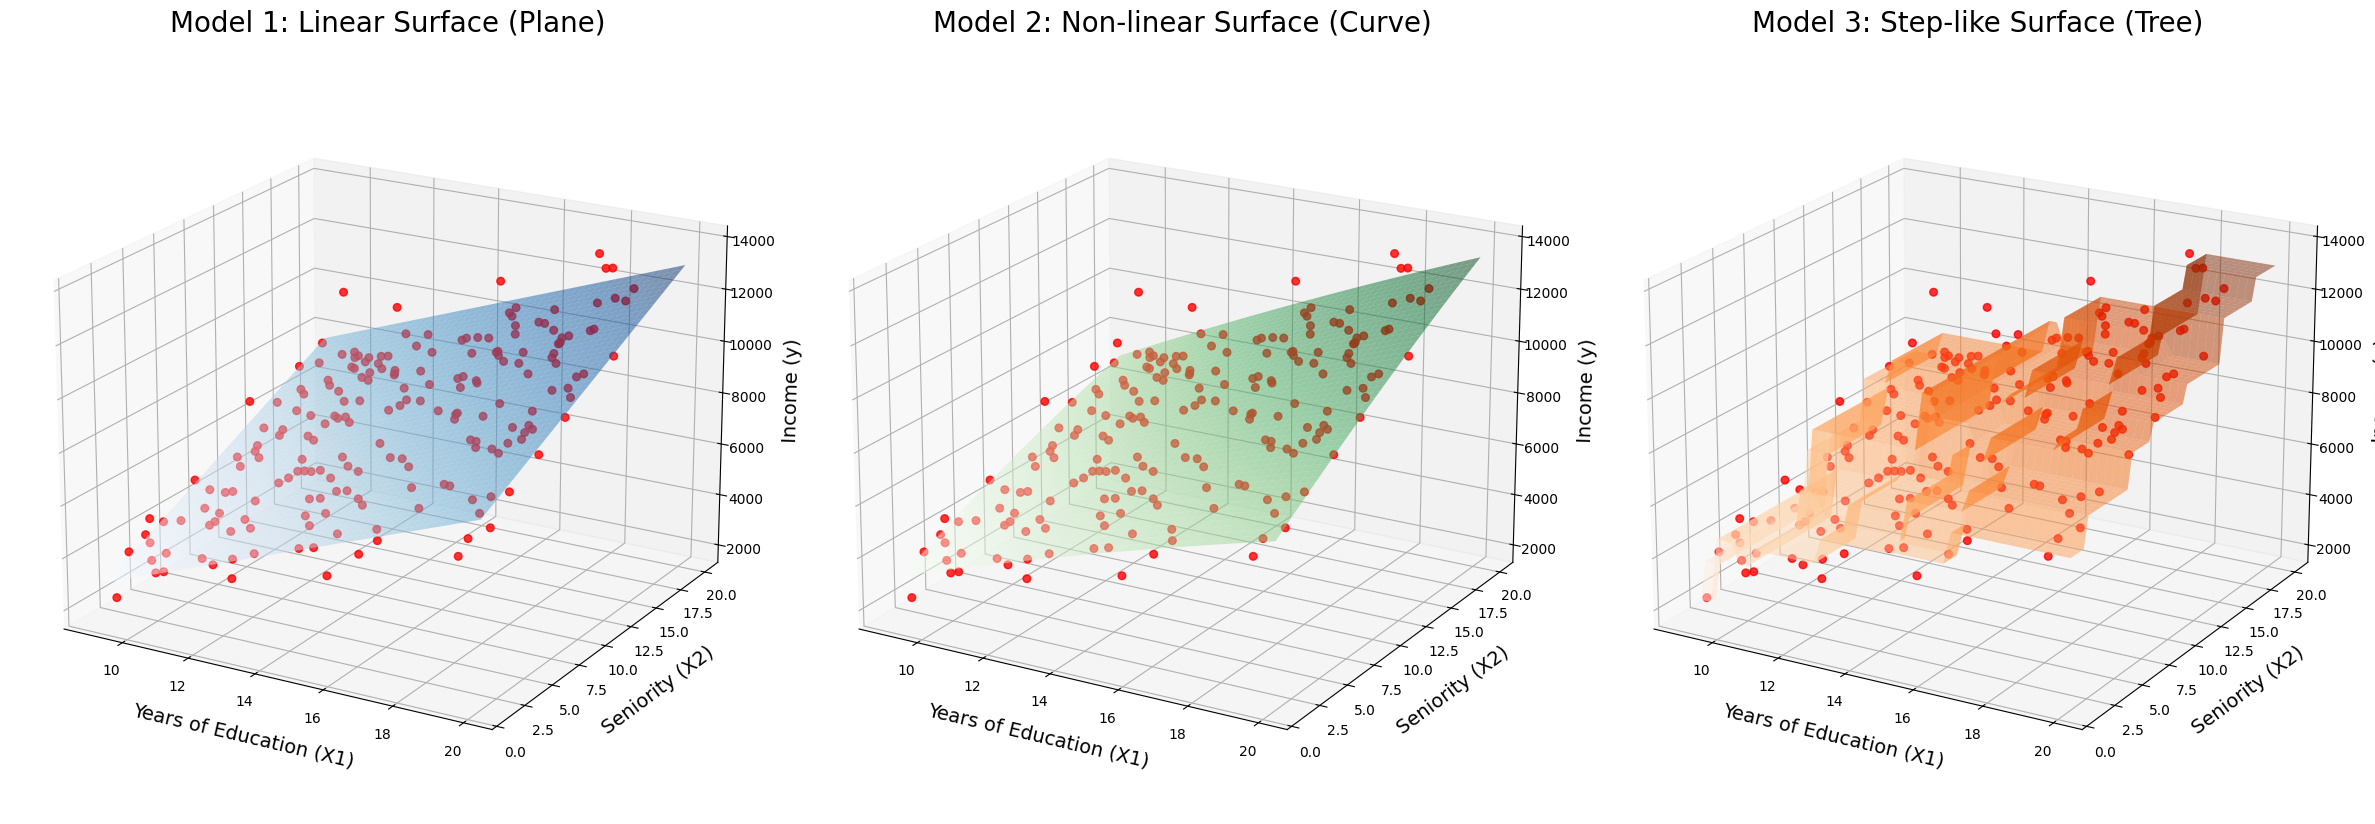

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

# 1. 데이터 준비 (데이터 포인트 200개로 대폭 확장)
np.random.seed(42)
num_samples = 200

# X1: 교육 연수 (9년 ~ 20년 사이의 랜덤한 값)
X1 = np.random.uniform(9, 20, num_samples)
# X2: 경력 (1년 ~ 20년 사이의 랜덤한 값)
X2 = np.random.uniform(1, 20, num_samples)

# y: 수입 (현실의 복잡성을 반영한 미지의 참 함수 f* + 노이즈)
# (단순한 직선이 아니라, 교육과 경력이 섞이고 곡선 형태를 띠도록 설정)
y_true = 1000 + 150 * X1 + 200 * X2 + 8 * (X1 ** 2) - 4 * (X2 ** 2) + 10 * (X1 * X2)
# 측정 오차(노이즈) 추가
y = y_true + np.random.normal(0, 800, num_samples)

# 학습용 데이터 합치기
X_train = np.column_stack((X1, X2))

# 3D 표면을 그리기 위한 촘촘한 그리드 도화지 생성
x1_grid = np.linspace(9, 20, 50)
x2_grid = np.linspace(1, 20, 50)
X1_surf, X2_surf = np.meshgrid(x1_grid, x2_grid)
X_surf = np.column_stack((X1_surf.ravel(), X2_surf.ravel()))

# 2. 세 가지 후보 모델 준비 및 예측

# [예시 모델 1] 선형 평면 (Linear Regression)
model_linear = LinearRegression()
model_linear.fit(X_train, y)
Z_surf_linear = model_linear.predict(X_surf).reshape(X1_surf.shape)

# [예시 모델 2] 비선형 곡면 (2차 다항식 회귀)
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_train, y)
Z_surf_poly = model_poly.predict(X_surf).reshape(X1_surf.shape)

# [예시 모델 3] 계단형 불연속 표면 (의사결정나무 모델)
# 깊이를 5로 설정하여 적당히 세밀한 계단을 만듦
model_tree = DecisionTreeRegressor(max_depth=5)
model_tree.fit(X_train, y)
Z_surf_tree = model_tree.predict(X_surf).reshape(X1_surf.shape)

# 3. 3D 시각화 (도화지 크기 확대: 가로 24, 세로 8)
fig = plt.figure(figsize=(24, 8))

def setup_3d_plot(ax, title, Z_surf, surf_color):
    # 데이터 포인트가 많아졌으므로 점 크기(s)를 줄이고 투명도(alpha) 조절
    ax.scatter(X1, X2, y, color='red', s=30, label='Real Data (200 pts)', zorder=10, alpha=0.8)
    
    # 모델의 예측 표면 그리기 (투명도를 0.5로 주어 점들이 잘 보이게 함)
    ax.plot_surface(X1_surf, X2_surf, Z_surf, cmap=surf_color, alpha=0.5, 
                    linewidth=0, antialiased=True)
    
    ax.set_title(title, fontsize=20, pad=20)
    ax.set_xlabel('Years of Education (X1)', fontsize=14, labelpad=10)
    ax.set_ylabel('Seniority (X2)', fontsize=14, labelpad=10)
    ax.set_zlabel('Income (y)', fontsize=14, labelpad=10)
    # z축 범위를 데이터에 맞게 여유롭게 설정
    ax.set_zlim(np.min(y) - 1000, np.max(y) + 1000)
    ax.view_init(elev=20, azim=-60)
    ax.grid(True, linestyle=':', alpha=0.5)

# --- 첫 번째 그래프: 모델 1 (선형 평면) ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
setup_3d_plot(ax1, 'Model 1: Linear Surface (Plane)', Z_surf_linear, cm.Blues)

# --- 두 번째 그래프: 모델 2 (비선형 곡면) ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
setup_3d_plot(ax2, 'Model 2: Non-linear Surface (Curve)', Z_surf_poly, cm.Greens)

# --- 세 번째 그래프: 모델 3 (계단형 불연속 표면) ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
setup_3d_plot(ax3, 'Model 3: Step-like Surface (Tree)', Z_surf_tree, cm.Oranges)

plt.tight_layout()
plt.show()